# AI Banking Churn Prediction System

# Phase 4 – Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to understand the customer dataset before building machine learning models.

We will:

- Explore the dataset structure
- Check data quality
- Analyze feature distributions
- Identify business patterns
- Derive insights for feature engineering and model development

---

**Author:** Arya Pathak

**Database:** PostgreSQL

**Dataset:** Customer Churn

**Target Variable:** Exited

In [8]:
# ==========================================
# Project Path Setup
# ==========================================

from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project Root:", project_root)

Project Root: d:\project\AI-Banking-Churn-System


In [9]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from src.database.queries import get_customer_data

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


In [10]:
df = get_customer_data()

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [11]:
df.head()

,row_number,customer_id,surname,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
df.shape

(10000, 14)

In [13]:
rows, columns = df.shape

print(f"Rows    : {rows}")
print(f"Columns : {columns}")

Rows    : 10000
Columns : 14


In [14]:
df.columns.tolist()

['row_number',
 'customer_id',
 'surname',
 'credit_score',
 'geography',
 'gender',
 'age',
 'tenure',
 'balance',
 'num_of_products',
 'has_cr_card',
 'is_active_member',
 'estimated_salary',
 'exited']

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   row_number        10000 non-null  int64  
 1   customer_id       10000 non-null  int64  
 2   surname           10000 non-null  object 
 3   credit_score      10000 non-null  int64  
 4   geography         10000 non-null  object 
 5   gender            10000 non-null  object 
 6   age               10000 non-null  int64  
 7   tenure            10000 non-null  int64  
 8   balance           10000 non-null  float64
 9   num_of_products   10000 non-null  int64  
 10  has_cr_card       10000 non-null  int64  
 11  is_active_member  10000 non-null  int64  
 12  estimated_salary  10000 non-null  float64
 13  exited            10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
row_number,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
customer_id,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
credit_score,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
num_of_products,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
has_cr_card,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
is_active_member,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
estimated_salary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [18]:
df.isnull().sum()

row_number          0
customer_id         0
surname             0
credit_score        0
geography           0
gender              0
age                 0
tenure              0
balance             0
num_of_products     0
has_cr_card         0
is_active_member    0
estimated_salary    0
exited              0
dtype: int64

In [19]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate Records: {duplicate_count}")

Duplicate Records: 0


## Observation

No missing values were found in any column.

This indicates that the dataset is complete and does not require missing value imputation before preprocessing.

In [21]:
duplicate_customer_ids = df["customer_id"].duplicated().sum()

print(f"Duplicate Customer IDs: {duplicate_customer_ids}")

Duplicate Customer IDs: 0


In [22]:
df["exited"].value_counts()

exited
0    7963
1    2037
Name: count, dtype: int64

In [24]:
target_summary = pd.DataFrame({
    "Count": df["exited"].value_counts(),
    "Percentage": (
        df["exited"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
})

target_summary

,Count,Percentage
exited,,
0,7963,79.63
1,2037,20.37


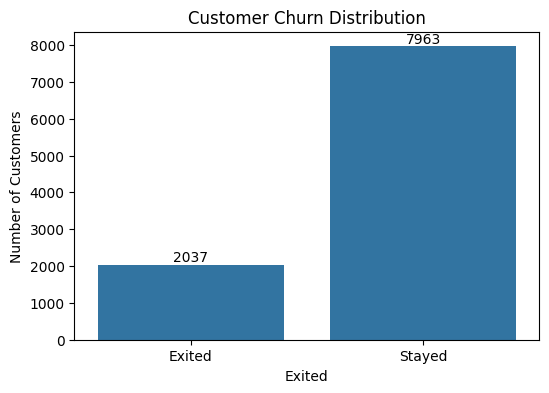

In [27]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x=df["exited"].map({0: "Stayed", 1: "Exited"})
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")

plt.show()

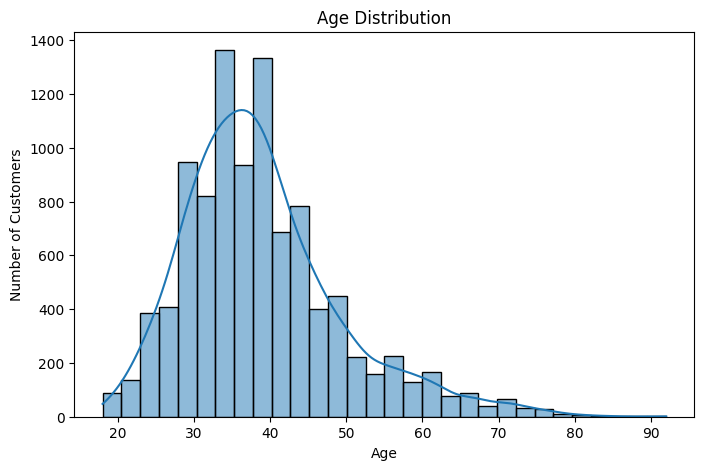

In [28]:
# Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

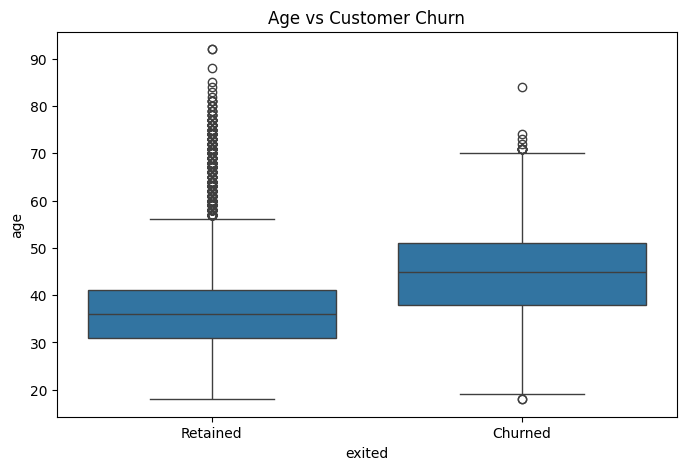

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="exited",
    y="age"
)

plt.xticks([0,1],["Retained","Churned"])

plt.title("Age vs Customer Churn")

plt.show()

In [30]:
df.groupby("exited")["age"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
exited,,,,,,,,
0,7963.0,37.41,10.13,18.0,31.0,36.0,41.0,92.0
1,2037.0,44.84,9.76,18.0,38.0,45.0,51.0,84.0


#geography analysis


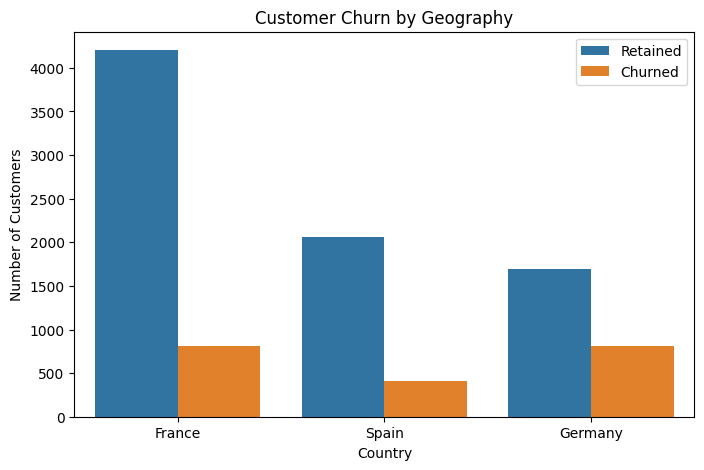

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="geography",
    hue="exited"
)

plt.title("Customer Churn by Geography")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

plt.legend(["Retained", "Churned"])

plt.show()

In [32]:
(
    df.groupby("geography")["exited"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

geography
Germany    32.44
Spain      16.67
France     16.15
Name: exited, dtype: float64

#gender analysis

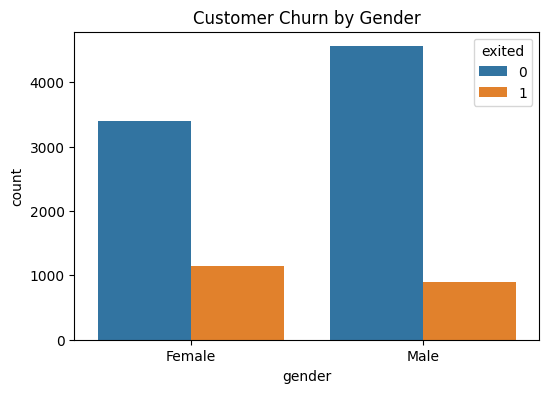

gender
Female    25.07
Male      16.46
Name: exited, dtype: float64

In [34]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="gender",
    hue="exited"
)

plt.title("Customer Churn by Gender")

plt.show()

(
    df.groupby("gender")["exited"]
      .mean()
      .mul(100)
      .round(2)
)

In [35]:
#active member analysis

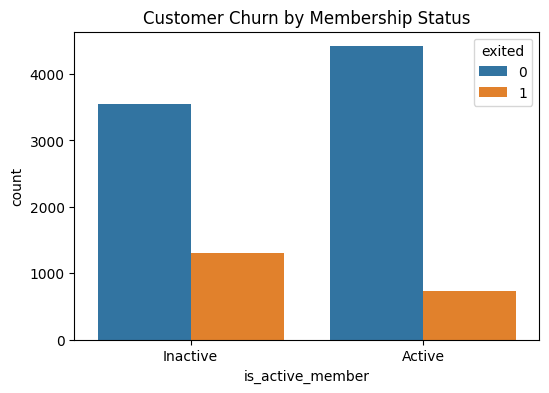

is_active_member
0    26.85
1    14.27
Name: exited, dtype: float64

In [36]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="is_active_member",
    hue="exited"
)

plt.xticks([0,1],["Inactive","Active"])

plt.title("Customer Churn by Membership Status")

plt.show()

(
    df.groupby("is_active_member")["exited"]
      .mean()
      .mul(100)
      .round(2)
)

#number of products

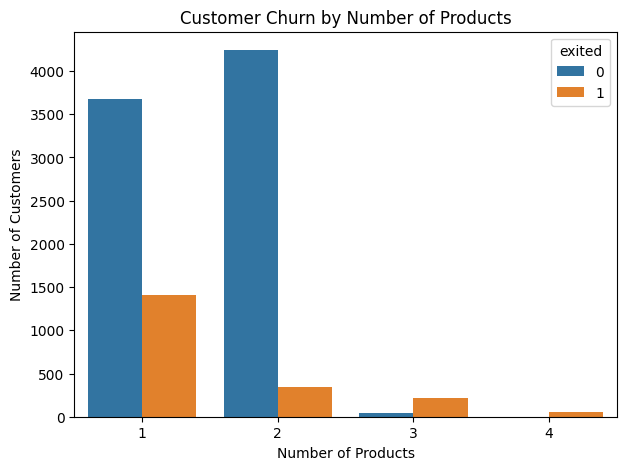

num_of_products
1     27.71
2      7.58
3     82.71
4    100.00
Name: exited, dtype: float64

In [38]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="num_of_products",
    hue="exited"
)

plt.title("Customer Churn by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Number of Customers")

plt.show()

(
    df.groupby("num_of_products")["exited"]
      .mean()
      .mul(100)
      .round(2)
)

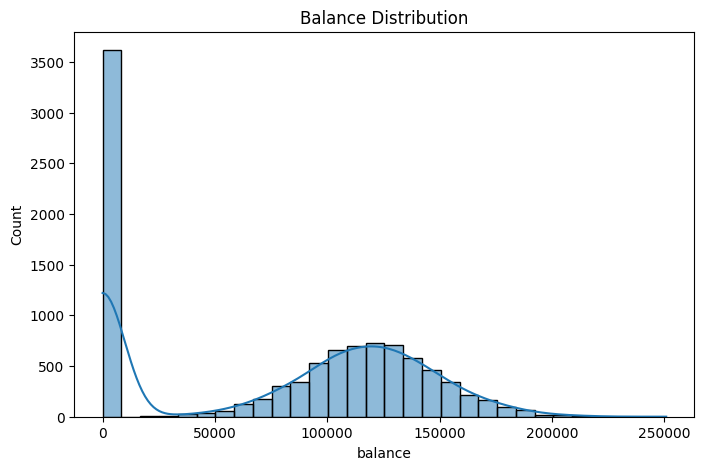

In [39]:
#balance analysis

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="balance",
    bins=30,
    kde=True
)

plt.title("Balance Distribution")

plt.show()

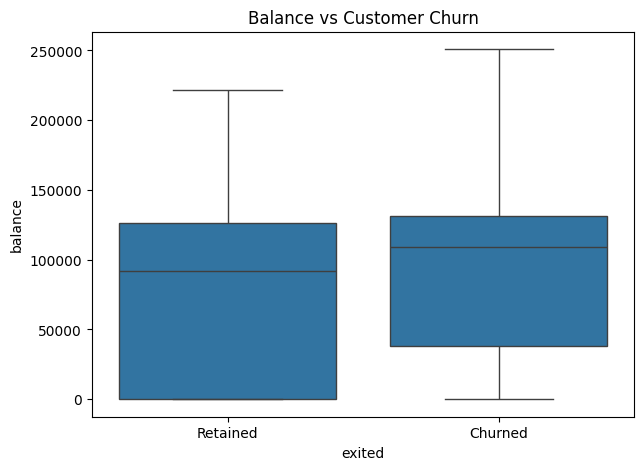

In [40]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="exited",
    y="balance"
)

plt.xticks([0,1],["Retained","Churned"])

plt.title("Balance vs Customer Churn")

plt.show()

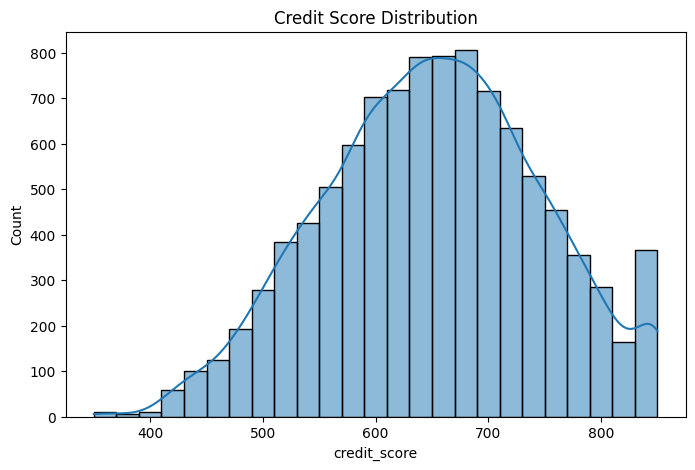

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="credit_score",
    bins=25,
    kde=True
)

plt.title("Credit Score Distribution")

plt.show()

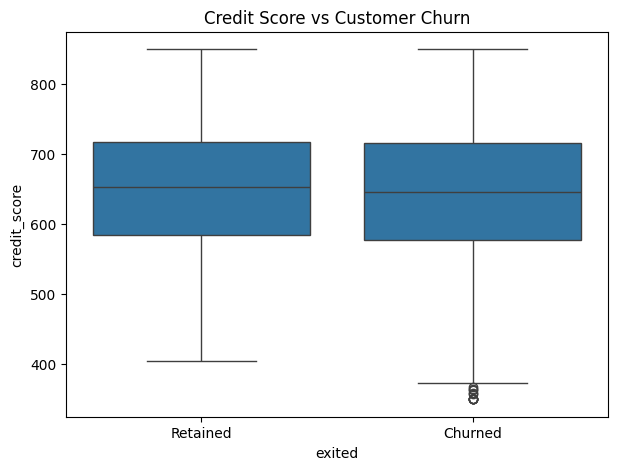

In [42]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="exited",
    y="credit_score"
)

plt.xticks([0,1],["Retained","Churned"])

plt.title("Credit Score vs Customer Churn")

plt.show()

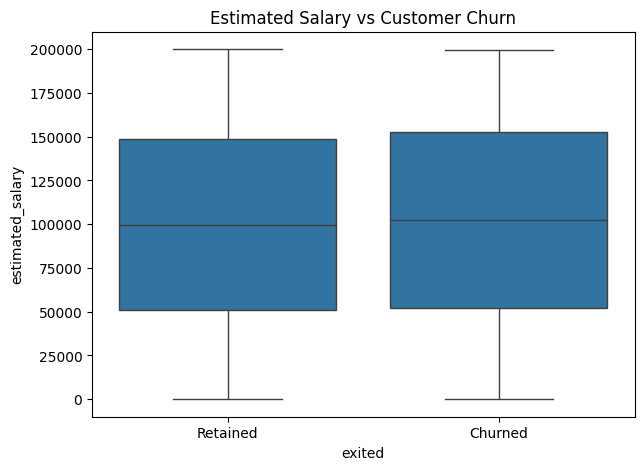

In [43]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="exited",
    y="estimated_salary"
)

plt.xticks([0,1],["Retained","Churned"])

plt.title("Estimated Salary vs Customer Churn")

plt.show()

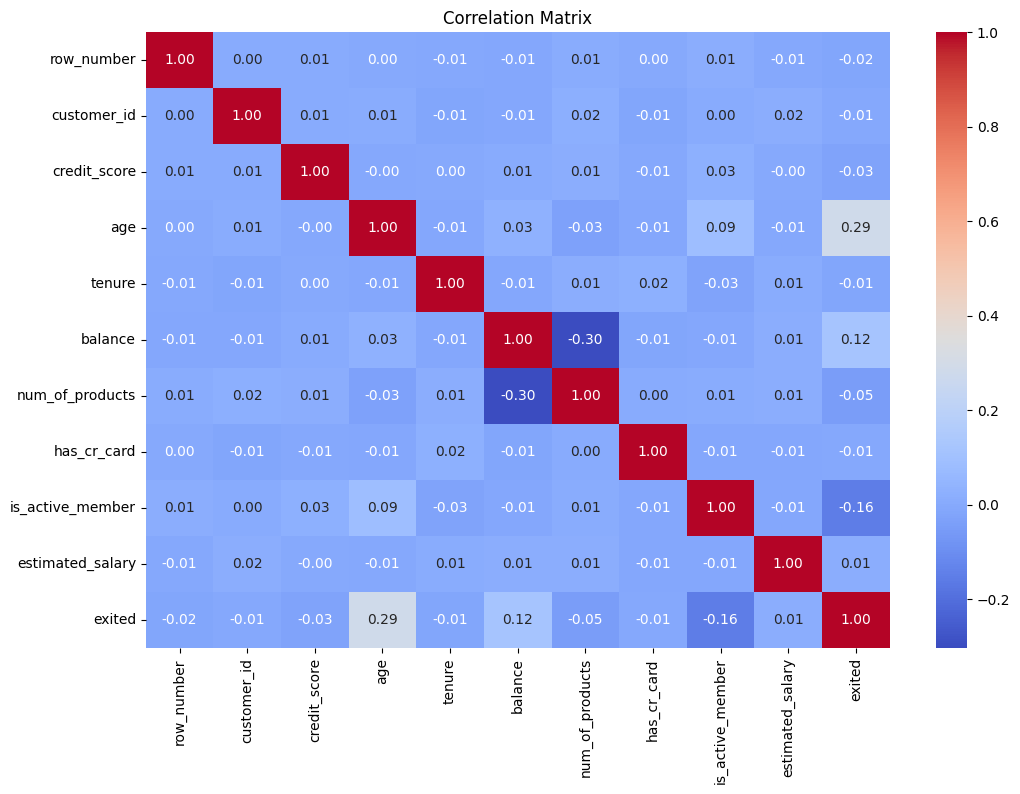

In [44]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

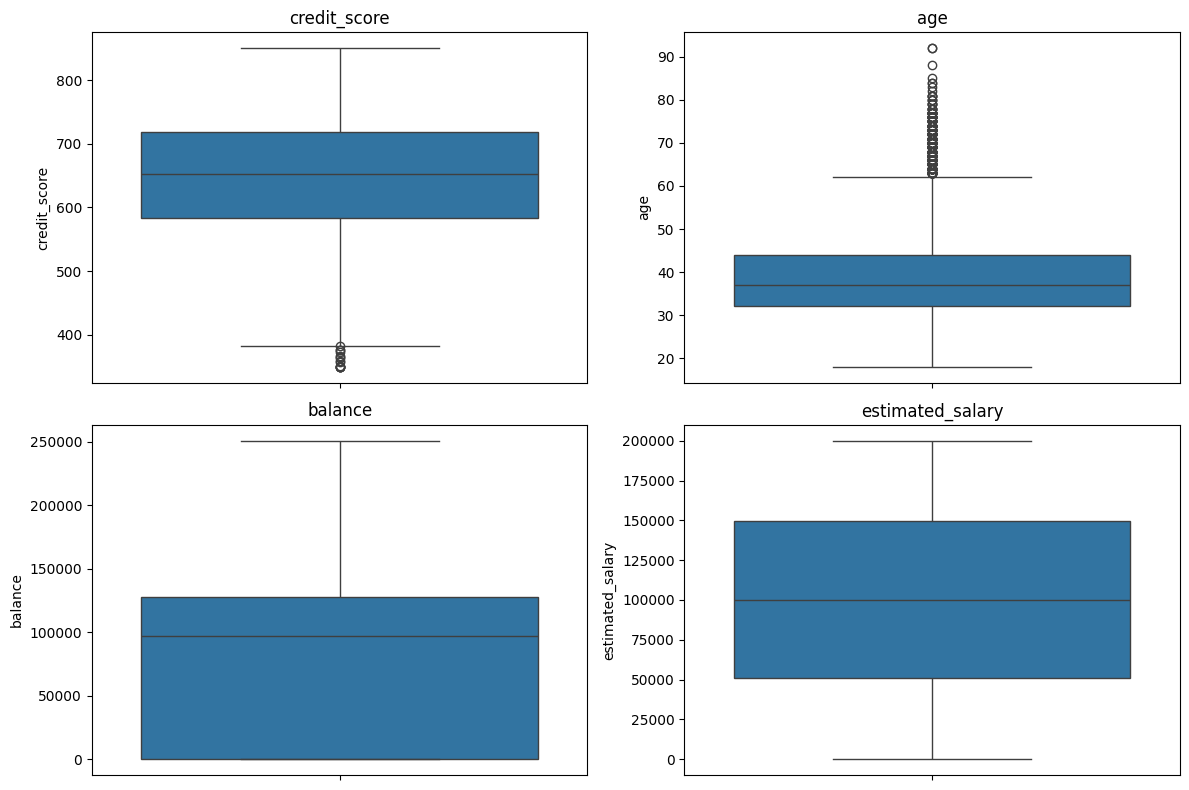

In [45]:
numeric_columns = [
    "credit_score",
    "age",
    "balance",
    "estimated_salary"
]

plt.figure(figsize=(12,8))

for i, column in enumerate(numeric_columns, 1):
    plt.subplot(2,2,i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()